In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
df = pd.read_csv("C:\\Users\\ASUS\\.vscode\\Factory-to-Customer Shipping Route Efficiency Analysis for Nassau Candy Distributor\\Nassau Candy Distributor.csv")

CHECKING NULL VALUES

In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

CHECK DUPLICATES

In [4]:
df.duplicated().sum()

np.int64(0)

CHECKING DATATYPE

In [5]:
df.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [6]:
df["Order Date"]=pd.to_datetime(df["Order Date"],format="%d-%m-%Y")
df["Ship Date"]=pd.to_datetime(df["Ship Date"],format="%d-%m-%Y")

ADD NEW LEAD DATE COLUMN

In [7]:
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days


COLUMNS

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_Time'],
      dtype='str')

Factory mapping dictionary (from project brief) and Add Factory Column

In [9]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df["Factory"] = df["Product Name"].map(factory_map)

In [10]:
missing_factories = df[df["Factory"].isna()]["Product Name"].unique()
print("Products without factory mapping:", missing_factories)

Products without factory mapping: <ArrowStringArray>
[]
Length: 0, dtype: str


ADD ROUGHT COLUMN

In [11]:
df["Route"] = df["Factory"] + " → " + df["State/Province"]


ROUTE AGGRIGATIONS

In [12]:
route_summary = df.groupby("Route").agg(
    Total_Shipments=("Order ID","count"),
    Avg_Lead_Time=("Lead_Time","mean"),
    LeadTime_Variability=("Lead_Time","std")
).reset_index()
route_summary



,Route,Total_Shipments,Avg_Lead_Time,LeadTime_Variability
0,Lot's O' Nuts → Alabama,34,1295.205882,253.070332
1,Lot's O' Nuts → Alberta,16,1273.875000,266.924428
2,Lot's O' Nuts → Arizona,111,1306.198198,253.901155
3,Lot's O' Nuts → Arkansas,31,1285.354839,274.529118
4,Lot's O' Nuts → British Columbia,18,1273.777778,307.082774
...,...,...,...,...
191,Wicked Choccy's → Vermont,5,1418.600000,200.285546
192,Wicked Choccy's → Virginia,106,1238.877358,254.774025
193,Wicked Choccy's → Washington,221,1375.723982,270.802982
194,Wicked Choccy's → West Virginia,2,1639.000000,0.000000


Top & Bottom routes

In [13]:
top10 = route_summary.nsmallest(10,"Avg_Lead_Time")
bottom10 = route_summary.nlargest(10,"Avg_Lead_Time")
top10.head()
bottom10.head()


,Route,Total_Shipments,Avg_Lead_Time,LeadTime_Variability
103,Sugar Shack → New Jersey,1,1642.0,NaN
78,Secret Factory → New Hampshire,1,1641.0,NaN
98,Sugar Shack → Connecticut,1,1641.0,NaN
194,Wicked Choccy's → West Virginia,2,1639.0,0.000000
37,Lot's O' Nuts → North Dakota,5,1638.2,1.643168


LEAD TIME DISTRIBUTION

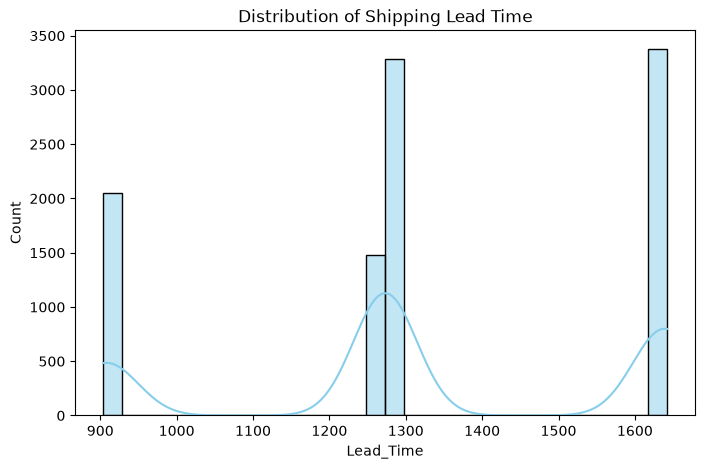

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["Lead_Time"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Shipping Lead Time")
plt.show()


ROUTE LEADERBOARD

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18664\4233907776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Route", y="Avg_Lead_Time", data=top10, palette="Greens")


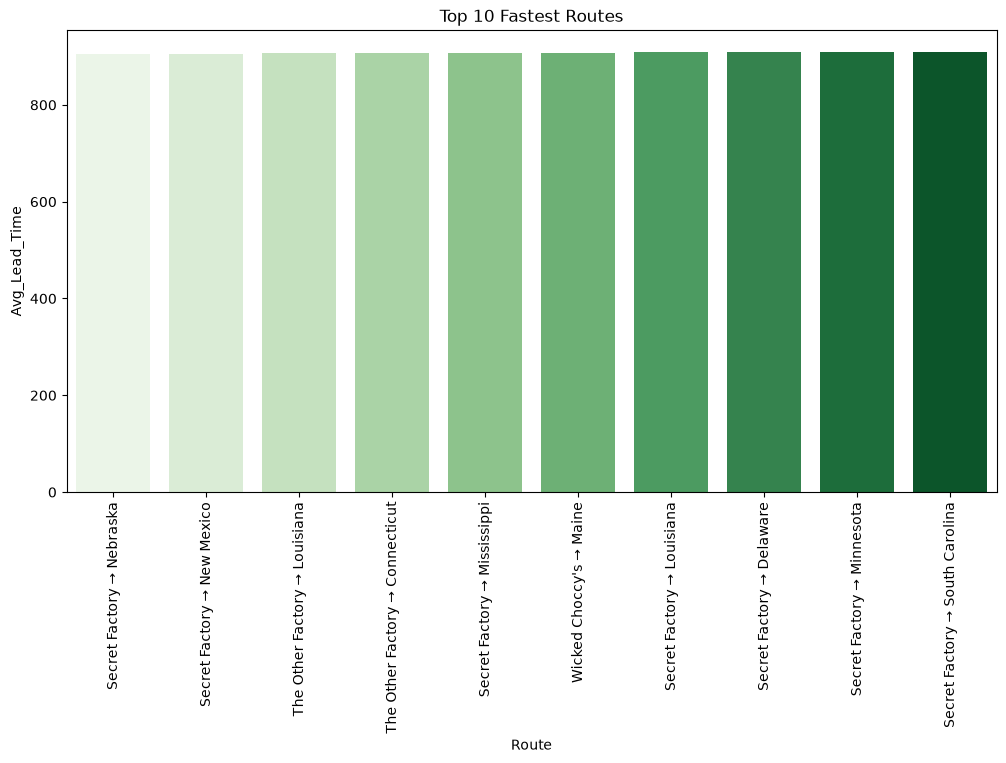

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18664\4233907776.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Route", y="Avg_Lead_Time", data=bottom10, palette="Reds")


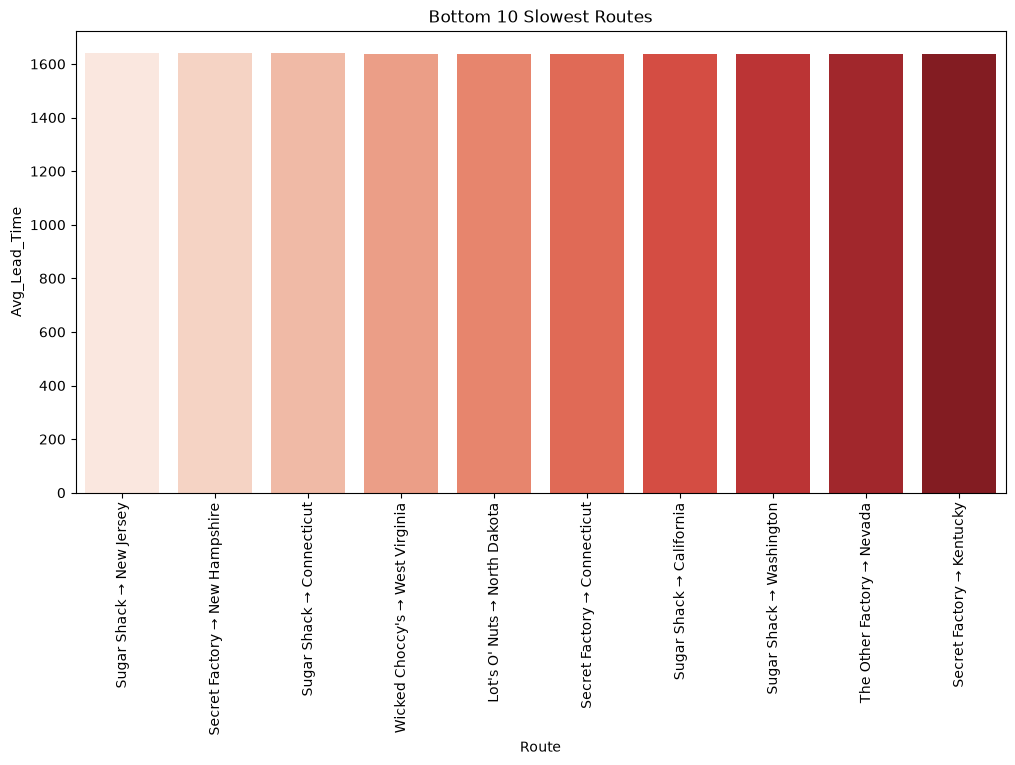

In [39]:
# Top 10 fastest routes chart
plt.figure(figsize=(12,6))
sns.barplot(x="Route", y="Avg_Lead_Time", data=top10, palette="Greens")
plt.xticks(rotation=90)
plt.title("Top 10 Fastest Routes")
plt.show()

# Bottom 10 slowest routes chart
plt.figure(figsize=(12,6))
sns.barplot(x="Route", y="Avg_Lead_Time", data=bottom10, palette="Reds")
plt.xticks(rotation=90)
plt.title("Bottom 10 Slowest Routes")
plt.show()


SHIPMODE COMPARISION

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18664\3411592686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ship Mode", y="Lead_Time", data=df, palette="Set2")


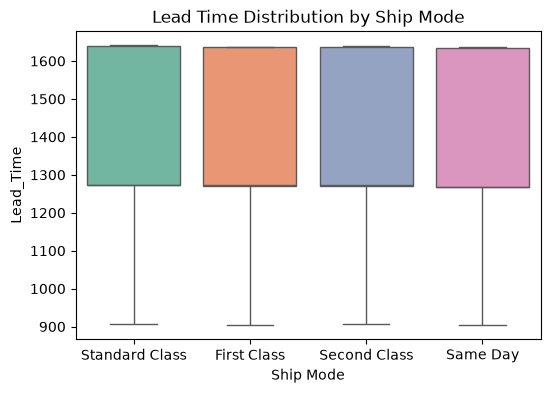

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Ship Mode", y="Lead_Time", data=df, palette="Set2")
plt.title("Lead Time Distribution by Ship Mode")
plt.show()


REGIONAL BOTTLENECK

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18664\2013630064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="Lead_Time", data=region_summary, palette="coolwarm")


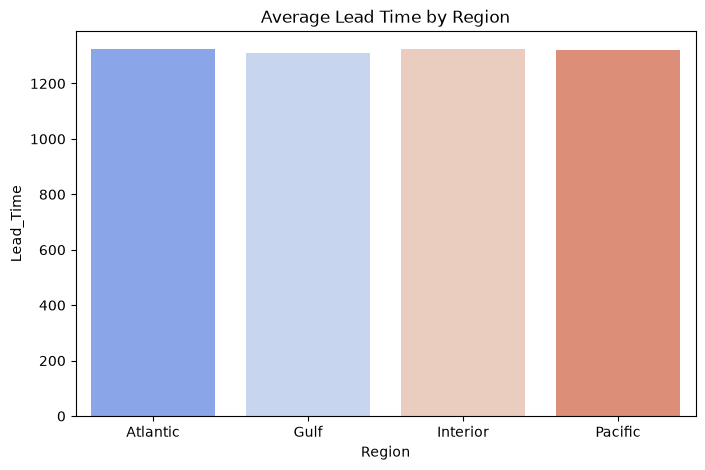

In [41]:
region_summary = df.groupby("Region")["Lead_Time"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Lead_Time", data=region_summary, palette="coolwarm")
plt.title("Average Lead Time by Region")
plt.show()
